Counting unique interactions to Phe141 …
Counting unique interactions to Ser408 …


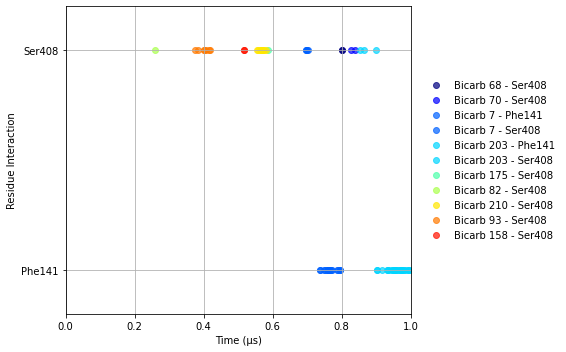


Finished. Data saved and plot generated.
Phe141 counts saved to O31_contacts_Phe141.txt
Ser408 counts saved to O31_contacts_Ser408.txt
Combined CSV saved to O31_contacts_combined.csv
Plot saved to contacts_vs_time_chainB.png


In [29]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import itertools
from MDAnalysis.analysis import distances

def count_unique_bicarb_interactions(u, resnum, bicarb_sel, cutoff=3.5, debug_frames=5):
    """
    Count unique bicarbonate residues (resname O31) interacting with a specific residue (resnum)
    within a cutoff distance, for each frame. Returns a list of sets, each containing unique
    interacting bicarbonate residue IDs for each frame.
    """
    res_group = u.select_atoms(f"protein and segid B and resid {resnum} and not name H*")
    if len(res_group) == 0:
        raise ValueError(f"No heavy atoms found for resid {resnum}")

    bicarb_group = u.select_atoms(f"{bicarb_sel} and not name H*")
    if len(bicarb_group) == 0:
        raise ValueError(f"No heavy atoms found for bicarbonate selection: {bicarb_sel}")

    b_resids = bicarb_group.resids
    res_inds = res_group.indices
    b_inds = bicarb_group.indices

    n_frames = len(u.trajectory)
    interacting_bicarbs = [set() for _ in range(n_frames)]

    for i, ts in enumerate(u.trajectory):
        res_pos = u.atoms[res_inds].positions
        b_pos = u.atoms[b_inds].positions

        pairs, dists = distances.capped_distance(
            res_pos, b_pos,
            max_cutoff=cutoff,
            box=u.dimensions,
            return_distances=True
        )

        if pairs.size > 0:
            mask = (dists < cutoff)
            valid_pairs = pairs[mask]
            b_atom_indices = valid_pairs[:, 1]
            interacting_resids = set(b_resids[b_atom_indices])
            interacting_bicarbs[i] = interacting_resids

        if i < debug_frames and interacting_bicarbs[i]:
            print(f"\nDEBUG: resid {resnum}, Frame {i}, interacting bicarb resids = {interacting_bicarbs[i]}")
            for (i_res, i_b), d in zip(pairs[mask], dists[mask]):
                atom_res = res_group.atoms[i_res]
                atom_b = bicarb_group.atoms[i_b]
                print(f"  Residue atom: {atom_res}, Bicarb atom: {atom_b}, distance = {d:.4f} Å, b_resid = {b_resids[i_b]}")
            print("-----")

    return interacting_bicarbs

def plot_unique_contacts(interacting_bicarbs_141, interacting_bicarbs_408,
                         time_ns_per_frame=1.0, plotfile="bicarb_contacts_vs_time_chainB.png"):
    """
    Plot the number of unique bicarbonate residues interacting with residues 141 and 408 over time.
    Each unique bicarbonate is represented by a distinct color.
    Only bicarbonates that appear at least once are shown in the legend.
    """
    n_frames = len(interacting_bicarbs_141)
    times_ns = np.arange(n_frames) * time_ns_per_frame
    times_us = times_ns / 1000.0  # convert ns → µs

    all_bicarbs = set()
    for frame_bicarbs in interacting_bicarbs_141 + interacting_bicarbs_408:
        all_bicarbs.update(frame_bicarbs)

    bicarb_to_color = {bicarb: plt.cm.jet(i / len(all_bicarbs)) for i, bicarb in enumerate(all_bicarbs)}

    plt.figure(figsize=(8, 5))
    used_labels = set()  # to prevent duplicate legend entries

    for bicarb in all_bicarbs:
        # Get the frames where each bicarb interacts with either residue
        times_141 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_141) if bicarb in frame_bicarbs]
        times_408 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_408) if bicarb in frame_bicarbs]

        # Only plot (and label) if it actually appears in at least one frame
        if times_141 or times_408:
            color = bicarb_to_color[bicarb]
            label_141 = f"Bicarb {bicarb} - Phe141" if bicarb not in used_labels and times_141 else None
            label_408 = f"Bicarb {bicarb} - Ser408" if bicarb not in used_labels and times_408 else None

            if times_141:
                plt.scatter(times_us[times_141], [1] * len(times_141), color=color,
                            label=label_141, alpha=0.7)
            if times_408:
                plt.scatter(times_us[times_408], [2] * len(times_408), color=color,
                            label=label_408, alpha=0.7)

            used_labels.add(bicarb)

    # === Axis and layout settings ===
    plt.xlabel("Time (µs)")
    plt.ylabel("Residue Interaction")
    plt.yticks([1, 2], ['Phe141', 'Ser408'])
    plt.xlim(0, 1)
    plt.ylim(0.8,2.2)
    plt.xticks(np.arange(0, 1.01, 0.2))

    # Legend outside plot (right side)
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(plotfile, dpi=300)
    plt.show() 

def main(topology, traj, cutoff=3.5, time_ns_per_frame=1.0, debug_frames=5, outprefix="bicarb_contacts", plotfile="contacts_vs_time.png"):
    u = mda.Universe(topology, traj)
    bicarb_sel = "resname O31"

    print("Counting unique interactions to Phe141 …")
    interacting_bicarbs_141 = count_unique_bicarb_interactions(u, 141, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)
    print("Counting unique interactions to Ser408 …")
    interacting_bicarbs_408 = count_unique_bicarb_interactions(u, 408, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)

    # Save data
    np.savetxt(f"{outprefix}_Phe141_chainB.txt", [len(frame) for frame in interacting_bicarbs_141], fmt="%d")
    np.savetxt(f"{outprefix}_Ser408_chainB.txt", [len(frame) for frame in interacting_bicarbs_408], fmt="%d")
    with open(f"{outprefix}_combined_chainB.csv", "w") as f:
        f.write("frame,time_us,Phe141,Ser408\n")
        for i in range(len(interacting_bicarbs_141)):
            time_us = (i * time_ns_per_frame) / 1000.0
            f.write(f"{i},{time_us:.6f},{len(interacting_bicarbs_141[i])},{len(interacting_bicarbs_408[i])}\n")

    # Plot
    plot_unique_contacts(interacting_bicarbs_141, interacting_bicarbs_408, time_ns_per_frame=time_ns_per_frame, plotfile=plotfile)

    print("\nFinished. Data saved and plot generated.")
    print(f"Phe141 counts saved to {outprefix}_Phe141.txt")
    print(f"Ser408 counts saved to {outprefix}_Ser408.txt")
    print(f"Combined CSV saved to {outprefix}_combined.csv")
    print(f"Plot saved to {plotfile}")

if __name__ == "__main__":
    # Example usage — change these to your real files
    topology = "pendrin_md_0ns.pdb"
    traj = "pendrin_md_0.5us.dcd"
    cutoff = 3.5
    time_ns_per_frame = 2  # 1 frame = 1 ns
    debug_frames = 5
    main(topology, traj, cutoff=cutoff,
         time_ns_per_frame=time_ns_per_frame,
         debug_frames=debug_frames,
         outprefix="O31_contacts", plotfile="contacts_vs_time_chainB.png")


Counting unique interactions to Phe141 …
Counting unique interactions to Ser408 …


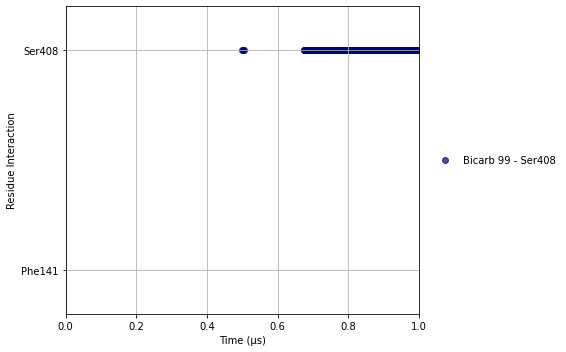


Finished. Data saved and plot generated.
Phe141 counts saved to O31_contacts_Phe141.txt
Ser408 counts saved to O31_contacts_Ser408.txt
Combined CSV saved to O31_contacts_combined.csv
Plot saved to contacts_vs_time_chainA.png


In [30]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis import distances

def count_unique_bicarb_interactions(u, resnum, bicarb_sel, cutoff=3.5, debug_frames=5):
    """
    Count unique bicarbonate residues (resname O31) interacting with a specific residue (resnum)
    within a cutoff distance, for each frame. Returns a list of sets, each containing unique
    interacting bicarbonate residue IDs for each frame.
    """
    res_group = u.select_atoms(f"protein and segid A and resid {resnum} and not name H*")
    if len(res_group) == 0:
        raise ValueError(f"No heavy atoms found for resid {resnum}")

    bicarb_group = u.select_atoms(f"{bicarb_sel} and not name H*")
    if len(bicarb_group) == 0:
        raise ValueError(f"No heavy atoms found for bicarbonate selection: {bicarb_sel}")

    b_resids = bicarb_group.resids
    res_inds = res_group.indices
    b_inds = bicarb_group.indices

    n_frames = len(u.trajectory)
    interacting_bicarbs = [set() for _ in range(n_frames)]

    for i, ts in enumerate(u.trajectory):
        res_pos = u.atoms[res_inds].positions
        b_pos = u.atoms[b_inds].positions

        pairs, dists = distances.capped_distance(
            res_pos, b_pos,
            max_cutoff=cutoff,
            box=u.dimensions,
            return_distances=True
        )

        if pairs.size > 0:
            mask = (dists < cutoff)
            valid_pairs = pairs[mask]
            b_atom_indices = valid_pairs[:, 1]
            interacting_resids = set(b_resids[b_atom_indices])
            interacting_bicarbs[i] = interacting_resids

        if i < debug_frames and interacting_bicarbs[i]:
            print(f"\nDEBUG: resid {resnum}, Frame {i}, interacting bicarb resids = {interacting_bicarbs[i]}")
            for (i_res, i_b), d in zip(pairs[mask], dists[mask]):
                atom_res = res_group.atoms[i_res]
                atom_b = bicarb_group.atoms[i_b]
                print(f"  Residue atom: {atom_res}, Bicarb atom: {atom_b}, distance = {d:.4f} Å, b_resid = {b_resids[i_b]}")
            print("-----")

    return interacting_bicarbs

def plot_unique_contacts(interacting_bicarbs_141, interacting_bicarbs_408,
                         time_ns_per_frame=1.0, plotfile="bicarb_contacts_vs_time_chainB.png"):
    """
    Plot the number of unique bicarbonate residues interacting with residues 141 and 408 over time.
    Each unique bicarbonate is represented by a distinct color.
    Only bicarbonates that appear at least once are shown in the legend.
    """
    n_frames = len(interacting_bicarbs_141)
    times_ns = np.arange(n_frames) * time_ns_per_frame
    times_us = times_ns / 1000.0  # convert ns → µs

    all_bicarbs = set()
    for frame_bicarbs in interacting_bicarbs_141 + interacting_bicarbs_408:
        all_bicarbs.update(frame_bicarbs)

    bicarb_to_color = {bicarb: plt.cm.jet(i / len(all_bicarbs)) for i, bicarb in enumerate(all_bicarbs)}

    plt.figure(figsize=(8, 5))
    used_labels = set()  # to prevent duplicate legend entries

    for bicarb in all_bicarbs:
        # Get the frames where each bicarb interacts with either residue
        times_141 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_141) if bicarb in frame_bicarbs]
        times_408 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_408) if bicarb in frame_bicarbs]

        # Only plot (and label) if it actually appears in at least one frame
        if times_141 or times_408:
            color = bicarb_to_color[bicarb]
            label_141 = f"Bicarb {bicarb} - Phe141" if bicarb not in used_labels and times_141 else None
            label_408 = f"Bicarb {bicarb} - Ser408" if bicarb not in used_labels and times_408 else None

            if times_141:
                plt.scatter(times_us[times_141], [1] * len(times_141), color=color,
                            label=label_141, alpha=0.7)
            if times_408:
                plt.scatter(times_us[times_408], [2] * len(times_408), color=color,
                            label=label_408, alpha=0.7)

            used_labels.add(bicarb)

    # === Axis and layout settings ===
    plt.xlabel("Time (µs)")
    plt.ylabel("Residue Interaction")
    plt.yticks([1, 2], ['Phe141', 'Ser408'])
    plt.xlim(0, 1)
    plt.ylim(0.8,2.2)
    plt.xticks(np.arange(0, 1.01, 0.2))

    # Legend outside plot (right side)
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(plotfile, dpi=300)
    plt.show() 

def main(topology, traj, cutoff=3.5, time_ns_per_frame=1.0, debug_frames=5, outprefix="bicarb_contacts", plotfile="contacts_vs_time.png"):
    u = mda.Universe(topology, traj)
    bicarb_sel = "resname O31"

    print("Counting unique interactions to Phe141 …")
    interacting_bicarbs_141 = count_unique_bicarb_interactions(u, 141, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)
    print("Counting unique interactions to Ser408 …")
    interacting_bicarbs_408 = count_unique_bicarb_interactions(u, 408, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)

    # Save data
    np.savetxt(f"{outprefix}_Phe141_chainA.txt", [len(frame) for frame in interacting_bicarbs_141], fmt="%d")
    np.savetxt(f"{outprefix}_Ser408_chainA.txt", [len(frame) for frame in interacting_bicarbs_408], fmt="%d")
    with open(f"{outprefix}_combined_chainA.csv", "w") as f:
        f.write("frame,time_us,Phe141,Ser408\n")
        for i in range(len(interacting_bicarbs_141)):
            time_us = (i * time_ns_per_frame) / 1000.0
            f.write(f"{i},{time_us:.6f},{len(interacting_bicarbs_141[i])},{len(interacting_bicarbs_408[i])}\n")

    # Plot
    plot_unique_contacts(interacting_bicarbs_141, interacting_bicarbs_408, time_ns_per_frame=time_ns_per_frame, plotfile=plotfile)

    print("\nFinished. Data saved and plot generated.")
    print(f"Phe141 counts saved to {outprefix}_Phe141.txt")
    print(f"Ser408 counts saved to {outprefix}_Ser408.txt")
    print(f"Combined CSV saved to {outprefix}_combined.csv")
    print(f"Plot saved to {plotfile}")

if __name__ == "__main__":
    # Example usage — change these to your real files
    topology = "pendrin_md_0ns.pdb"
    traj = "pendrin_md_0.5us.dcd"
    cutoff = 3.5
    time_ns_per_frame = 2  # 1 frame = 1 ns
    debug_frames = 5
    main(topology, traj, cutoff=cutoff,
         time_ns_per_frame=time_ns_per_frame,
         debug_frames=debug_frames,
         outprefix="O31_contacts", plotfile="contacts_vs_time_chainA.png")

Counting unique interactions to Tyr105 …
Counting unique interactions to Ser408 …


No handles with labels found to put in legend.


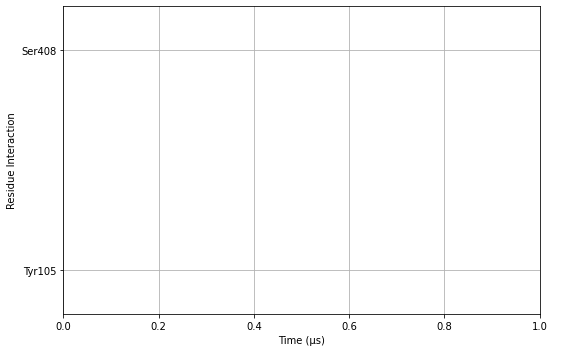


Finished. Data saved and plot generated.
Phe141 counts saved to CLA_contacts_Tyr105.txt
Ser408 counts saved to CLA_contacts_Ser408.txt
Combined CSV saved to CLA_contacts_combined.csv
Plot saved to CLA_contacts_vs_time_chainA.png


In [31]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis import distances

def count_unique_bicarb_interactions(u, resnum, bicarb_sel, cutoff=3.5, debug_frames=5):
    """
    Count unique bicarbonate residues (resname O31) interacting with a specific residue (resnum)
    within a cutoff distance, for each frame. Returns a list of sets, each containing unique
    interacting chloride residue IDs for each frame.
    """
    res_group = u.select_atoms(f"protein and segid A and resid {resnum} and not name H*")
    if len(res_group) == 0:
        raise ValueError(f"No heavy atoms found for resid {resnum}")

    bicarb_group = u.select_atoms(f"{bicarb_sel} and not name H*")
    if len(bicarb_group) == 0:
        raise ValueError(f"No heavy atoms found for chloride selection: {bicarb_sel}")

    b_resids = bicarb_group.resids
    res_inds = res_group.indices
    b_inds = bicarb_group.indices

    n_frames = len(u.trajectory)
    interacting_bicarbs = [set() for _ in range(n_frames)]

    for i, ts in enumerate(u.trajectory):
        res_pos = u.atoms[res_inds].positions
        b_pos = u.atoms[b_inds].positions

        pairs, dists = distances.capped_distance(
            res_pos, b_pos,
            max_cutoff=cutoff,
            box=u.dimensions,
            return_distances=True
        )

        if pairs.size > 0:
            mask = (dists < cutoff)
            valid_pairs = pairs[mask]
            b_atom_indices = valid_pairs[:, 1]
            interacting_resids = set(b_resids[b_atom_indices])
            interacting_bicarbs[i] = interacting_resids

        if i < debug_frames and interacting_bicarbs[i]:
            print(f"\nDEBUG: resid {resnum}, Frame {i}, interacting bicarb resids = {interacting_bicarbs[i]}")
            for (i_res, i_b), d in zip(pairs[mask], dists[mask]):
                atom_res = res_group.atoms[i_res]
                atom_b = bicarb_group.atoms[i_b]
                print(f"  Residue atom: {atom_res}, Chloride atom: {atom_b}, distance = {d:.4f} Å, b_resid = {b_resids[i_b]}")
            print("-----")

    return interacting_bicarbs

def plot_unique_contacts(interacting_bicarbs_141, interacting_bicarbs_408,
                         time_ns_per_frame=1.0, plotfile="chloride_contacts_vs_time_chainB.png"):
    """
    Plot the number of unique chloride residues interacting with residues 141 and 408 over time.
    Each unique chloride is represented by a distinct color.
    Only chloride that appear at least once are shown in the legend.
    """
    n_frames = len(interacting_bicarbs_141)
    times_ns = np.arange(n_frames) * time_ns_per_frame
    times_us = times_ns / 1000.0  # convert ns → µs

    all_bicarbs = set()
    for frame_bicarbs in interacting_bicarbs_141 + interacting_bicarbs_408:
        all_bicarbs.update(frame_bicarbs)

    bicarb_to_color = {bicarb: plt.cm.jet(i / len(all_bicarbs)) for i, bicarb in enumerate(all_bicarbs)}

    plt.figure(figsize=(8, 5))
    used_labels = set()  # to prevent duplicate legend entries

    for bicarb in all_bicarbs:
        # Get the frames where each chloride interacts with either residue
        times_141 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_141) if bicarb in frame_bicarbs]
        times_408 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_408) if bicarb in frame_bicarbs]

        # Only plot (and label) if it actually appears in at least one frame
        if times_141 or times_408:
            color = bicarb_to_color[bicarb]
            label_141 = f"Chloride {bicarb} - Tyr105" if bicarb not in used_labels and times_141 else None
            label_408 = f"Chloride {bicarb} - Ser408" if bicarb not in used_labels and times_408 else None

            if times_141:
                plt.scatter(times_us[times_141], [1] * len(times_141), color=color,
                            label=label_141, alpha=0.7)
            if times_408:
                plt.scatter(times_us[times_408], [2] * len(times_408), color=color,
                            label=label_408, alpha=0.7)

            used_labels.add(bicarb)

    # === Axis and layout settings ===
    plt.xlabel("Time (µs)")
    plt.ylabel("Residue Interaction")
    plt.yticks([1, 2], ['Tyr105', 'Ser408'])
    plt.xlim(0, 1)
    plt.ylim(0.8,2.2)
    plt.xticks(np.arange(0, 1.01, 0.2))

    # Legend outside plot (right side)
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(plotfile, dpi=300)
    plt.show() 

def main(topology, traj, cutoff=3.5, time_ns_per_frame=1.0, debug_frames=5, outprefix="bicarb_contacts", plotfile="contacts_vs_time.png"):
    u = mda.Universe(topology, traj)
    bicarb_sel = "resname CLA"

    print("Counting unique interactions to Tyr105 …")
    interacting_bicarbs_141 = count_unique_bicarb_interactions(u, 105, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)
    print("Counting unique interactions to Ser408 …")
    interacting_bicarbs_408 = count_unique_bicarb_interactions(u, 408, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)

    # Save data
    np.savetxt(f"{outprefix}_Tyr105_chainA.txt", [len(frame) for frame in interacting_bicarbs_141], fmt="%d")
    np.savetxt(f"{outprefix}_Ser408_chainA.txt", [len(frame) for frame in interacting_bicarbs_408], fmt="%d")
    with open(f"{outprefix}_combined_chainA.csv", "w") as f:
        f.write("frame,time_us,Tyr105,Ser408\n")
        for i in range(len(interacting_bicarbs_141)):
            time_us = (i * time_ns_per_frame) / 1000.0
            f.write(f"{i},{time_us:.6f},{len(interacting_bicarbs_141[i])},{len(interacting_bicarbs_408[i])}\n")

    # Plot
    plot_unique_contacts(interacting_bicarbs_141, interacting_bicarbs_408, time_ns_per_frame=time_ns_per_frame, plotfile=plotfile)

    print("\nFinished. Data saved and plot generated.")
    print(f"Phe141 counts saved to {outprefix}_Tyr105.txt")
    print(f"Ser408 counts saved to {outprefix}_Ser408.txt")
    print(f"Combined CSV saved to {outprefix}_combined.csv")
    print(f"Plot saved to {plotfile}")

if __name__ == "__main__":
    # Example usage — change these to your real files
    topology = "pendrin_md_0ns.pdb"
    traj = "pendrin_md_0.5us.dcd"
    cutoff = 3.5
    time_ns_per_frame = 2  # 1 frame = 1 ns
    debug_frames = 5
    main(topology, traj, cutoff=cutoff,
         time_ns_per_frame=time_ns_per_frame,
         debug_frames=debug_frames,
         outprefix="CLA_contacts", plotfile="CLA_contacts_vs_time_chainA.png")

Counting unique interactions to Tyr105 …
Counting unique interactions to Ser408 …


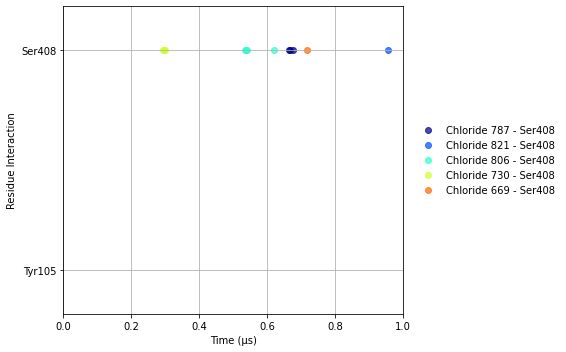


Finished. Data saved and plot generated.
Phe141 counts saved to CLA_contacts_Tyr105.txt
Ser408 counts saved to CLA_contacts_Ser408.txt
Combined CSV saved to CLA_contacts_combined.csv
Plot saved to CLA_contacts_vs_time_chainB.png


In [33]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis import distances

def count_unique_bicarb_interactions(u, resnum, bicarb_sel, cutoff=3.5, debug_frames=5):
    """
    Count unique chloride residues (resname O31) interacting with a specific residue (resnum)
    within a cutoff distance, for each frame. Returns a list of sets, each containing unique
    interacting chloride residue IDs for each frame.
    """
    res_group = u.select_atoms(f"protein and segid B and resid {resnum} and not name H*")
    if len(res_group) == 0:
        raise ValueError(f"No heavy atoms found for resid {resnum}")

    bicarb_group = u.select_atoms(f"{bicarb_sel} and not name H*")
    if len(bicarb_group) == 0:
        raise ValueError(f"No heavy atoms found for chloride selection: {bicarb_sel}")

    b_resids = bicarb_group.resids
    res_inds = res_group.indices
    b_inds = bicarb_group.indices

    n_frames = len(u.trajectory)
    interacting_bicarbs = [set() for _ in range(n_frames)]

    for i, ts in enumerate(u.trajectory):
        res_pos = u.atoms[res_inds].positions
        b_pos = u.atoms[b_inds].positions

        pairs, dists = distances.capped_distance(
            res_pos, b_pos,
            max_cutoff=cutoff,
            box=u.dimensions,
            return_distances=True
        )

        if pairs.size > 0:
            mask = (dists < cutoff)
            valid_pairs = pairs[mask]
            b_atom_indices = valid_pairs[:, 1]
            interacting_resids = set(b_resids[b_atom_indices])
            interacting_bicarbs[i] = interacting_resids

        if i < debug_frames and interacting_bicarbs[i]:
            print(f"\nDEBUG: resid {resnum}, Frame {i}, interacting bicarb resids = {interacting_bicarbs[i]}")
            for (i_res, i_b), d in zip(pairs[mask], dists[mask]):
                atom_res = res_group.atoms[i_res]
                atom_b = bicarb_group.atoms[i_b]
                print(f"  Residue atom: {atom_res}, Chloride atom: {atom_b}, distance = {d:.4f} Å, b_resid = {b_resids[i_b]}")
            print("-----")

    return interacting_bicarbs

def plot_unique_contacts(interacting_bicarbs_141, interacting_bicarbs_408,
                         time_ns_per_frame=1.0, plotfile="chloride_contacts_vs_time_chainB.png"):
    """
    Plot the number of unique chloride residues interacting with residues 141 and 408 over time.
    Each unique chloride is represented by a distinct color.
    Only chloride that appear at least once are shown in the legend.
    """
    n_frames = len(interacting_bicarbs_141)
    times_ns = np.arange(n_frames) * time_ns_per_frame
    times_us = times_ns / 1000.0  # convert ns → µs

    all_bicarbs = set()
    for frame_bicarbs in interacting_bicarbs_141 + interacting_bicarbs_408:
        all_bicarbs.update(frame_bicarbs)

    bicarb_to_color = {bicarb: plt.cm.jet(i / len(all_bicarbs)) for i, bicarb in enumerate(all_bicarbs)}

    plt.figure(figsize=(8, 5))
    used_labels = set()  # to prevent duplicate legend entries

    for bicarb in all_bicarbs:
        # Get the frames where each chloride interacts with either residue
        times_141 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_141) if bicarb in frame_bicarbs]
        times_408 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_408) if bicarb in frame_bicarbs]

        # Only plot (and label) if it actually appears in at least one frame
        if times_141 or times_408:
            color = bicarb_to_color[bicarb]
            label_141 = f"Chloride {bicarb} - Tyr105" if bicarb not in used_labels and times_141 else None
            label_408 = f"Chloride {bicarb} - Ser408" if bicarb not in used_labels and times_408 else None

            if times_141:
                plt.scatter(times_us[times_141], [1] * len(times_141), color=color,
                            label=label_141, alpha=0.7)
            if times_408:
                plt.scatter(times_us[times_408], [2] * len(times_408), color=color,
                            label=label_408, alpha=0.7)

            used_labels.add(bicarb)

    # === Axis and layout settings ===
    plt.xlabel("Time (µs)")
    plt.ylabel("Residue Interaction")
    plt.yticks([1, 2], ['Tyr105', 'Ser408'])
    plt.xlim(0, 1)
    plt.ylim(0.8,2.2)
    plt.xticks(np.arange(0, 1.01, 0.2))

    # Legend outside plot (right side)
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(plotfile, dpi=300)
    plt.show() 

def main(topology, traj, cutoff=3.5, time_ns_per_frame=1.0, debug_frames=5, outprefix="bicarb_contacts", plotfile="contacts_vs_time.png"):
    u = mda.Universe(topology, traj)
    bicarb_sel = "resname CLA"

    print("Counting unique interactions to Tyr105 …")
    interacting_bicarbs_141 = count_unique_bicarb_interactions(u, 105, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)
    print("Counting unique interactions to Ser408 …")
    interacting_bicarbs_408 = count_unique_bicarb_interactions(u, 408, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)

    # Save data
    np.savetxt(f"{outprefix}_Phe141_chainB.txt", [len(frame) for frame in interacting_bicarbs_141], fmt="%d")
    np.savetxt(f"{outprefix}_Ser408_chainB.txt", [len(frame) for frame in interacting_bicarbs_408], fmt="%d")
    with open(f"{outprefix}_combined_chainB.csv", "w") as f:
        f.write("frame,time_us,Tyr105,Ser408\n")
        for i in range(len(interacting_bicarbs_141)):
            time_us = (i * time_ns_per_frame) / 1000.0
            f.write(f"{i},{time_us:.6f},{len(interacting_bicarbs_141[i])},{len(interacting_bicarbs_408[i])}\n")

    # Plot
    plot_unique_contacts(interacting_bicarbs_141, interacting_bicarbs_408, time_ns_per_frame=time_ns_per_frame, plotfile=plotfile)

    print("\nFinished. Data saved and plot generated.")
    print(f"Phe141 counts saved to {outprefix}_Tyr105.txt")
    print(f"Ser408 counts saved to {outprefix}_Ser408.txt")
    print(f"Combined CSV saved to {outprefix}_combined.csv")
    print(f"Plot saved to {plotfile}")

if __name__ == "__main__":
    # Example usage — change these to your real files
    topology = "pendrin_md_0ns.pdb"
    traj = "pendrin_md_0.5us.dcd"
    cutoff = 3.5
    time_ns_per_frame = 2  # 1 frame = 1 ns
    debug_frames = 5
    main(topology, traj, cutoff=cutoff,
         time_ns_per_frame=time_ns_per_frame,
         debug_frames=debug_frames,
         outprefix="CLA_contacts", plotfile="CLA_contacts_vs_time_chainB.png")

Counting unique interactions to Gln230 …
Counting unique interactions to Ser237 …


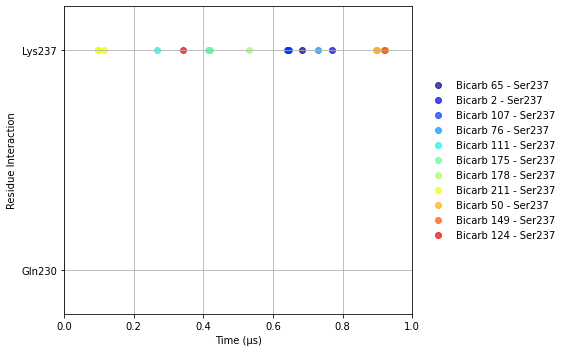


Finished. Data saved and plot generated.
Gln230 counts saved to Bicarb_contacts_Gln230.txt
Lys237 counts saved to Bicarb_contacts_Lys237.txt
Combined CSV saved to Bicarb_contacts_combined.csv
Plot saved to Bicarb_contacts_vs_time_chainA.png


In [1]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis import distances

def count_unique_bicarb_interactions(u, resnum, bicarb_sel, cutoff=3.5, debug_frames=5):
    """
    Count unique bicarbonate residues (resname O31) interacting with a specific residue (resnum)
    within a cutoff distance, for each frame. Returns a list of sets, each containing unique
    interacting chloride residue IDs for each frame.
    """
    res_group = u.select_atoms(f"protein and segid A and resid {resnum} and not name H*")
    if len(res_group) == 0:
        raise ValueError(f"No heavy atoms found for resid {resnum}")

    bicarb_group = u.select_atoms(f"{bicarb_sel} and not name H*")
    if len(bicarb_group) == 0:
        raise ValueError(f"No heavy atoms found for chloride selection: {bicarb_sel}")

    b_resids = bicarb_group.resids
    res_inds = res_group.indices
    b_inds = bicarb_group.indices

    n_frames = len(u.trajectory)
    interacting_bicarbs = [set() for _ in range(n_frames)]

    for i, ts in enumerate(u.trajectory):
        res_pos = u.atoms[res_inds].positions
        b_pos = u.atoms[b_inds].positions

        pairs, dists = distances.capped_distance(
            res_pos, b_pos,
            max_cutoff=cutoff,
            box=u.dimensions,
            return_distances=True
        )

        if pairs.size > 0:
            mask = (dists < cutoff)
            valid_pairs = pairs[mask]
            b_atom_indices = valid_pairs[:, 1]
            interacting_resids = set(b_resids[b_atom_indices])
            interacting_bicarbs[i] = interacting_resids

        if i < debug_frames and interacting_bicarbs[i]:
            print(f"\nDEBUG: resid {resnum}, Frame {i}, interacting bicarb resids = {interacting_bicarbs[i]}")
            for (i_res, i_b), d in zip(pairs[mask], dists[mask]):
                atom_res = res_group.atoms[i_res]
                atom_b = bicarb_group.atoms[i_b]
                print(f"  Residue atom: {atom_res}, Bicarbonate atom: {atom_b}, distance = {d:.4f} Å, b_resid = {b_resids[i_b]}")
            print("-----")

    return interacting_bicarbs

def plot_unique_contacts(interacting_bicarbs_230, interacting_bicarbs_237,
                         time_ns_per_frame=1.0, plotfile="bicarbonate_contacts_vs_time_chainA_out.png"):
    """
    Plot the number of unique chloride residues interacting with residues 230 and 237 over time.
    Each unique chloride is represented by a distinct color.
    Only chloride that appear at least once are shown in the legend.
    """
    n_frames = len(interacting_bicarbs_230)
    times_ns = np.arange(n_frames) * time_ns_per_frame
    times_us = times_ns / 1000.0  # convert ns → µs

    all_bicarbs = set()
    for frame_bicarbs in interacting_bicarbs_230 + interacting_bicarbs_237:
        all_bicarbs.update(frame_bicarbs)

    bicarb_to_color = {bicarb: plt.cm.jet(i / len(all_bicarbs)) for i, bicarb in enumerate(all_bicarbs)}

    plt.figure(figsize=(8, 5))
    used_labels = set()  # to prevent duplicate legend entries

    for bicarb in all_bicarbs:
        # Get the frames where each chloride interacts with either residue
        times_230 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_230) if bicarb in frame_bicarbs]
        times_237 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_237) if bicarb in frame_bicarbs]

        # Only plot (and label) if it actually appears in at least one frame
        if times_230 or times_237:
            color = bicarb_to_color[bicarb]
            label_230 = f"Bicarb {bicarb} - Tyr230" if bicarb not in used_labels and times_230 else None
            label_237 = f"Bicarb {bicarb} - Ser237" if bicarb not in used_labels and times_237 else None

            if times_230:
                plt.scatter(times_us[times_230], [1] * len(times_230), color=color,
                            label=label_230, alpha=0.7)
            if times_237:
                plt.scatter(times_us[times_237], [2] * len(times_237), color=color,
                            label=label_237, alpha=0.7)

            used_labels.add(bicarb)

    # === Axis and layout settings ===
    plt.xlabel("Time (µs)")
    plt.ylabel("Residue Interaction")
    plt.yticks([1, 2], ['Gln230', 'Lys237'])
    plt.xlim(0, 1)
    plt.ylim(0.8,2.2)
    plt.xticks(np.arange(0, 1.01, 0.2))

    # Legend outside plot (right side)
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(plotfile, dpi=300)
    plt.show() 

def main(topology, traj, cutoff=3.5, time_ns_per_frame=1.0, debug_frames=5, outprefix="bicarb_contacts", plotfile="contacts_vs_time_outface.png"):
    u = mda.Universe(topology, traj)
    bicarb_sel = "resname O31"

    print("Counting unique interactions to Gln230 …")
    interacting_bicarbs_230 = count_unique_bicarb_interactions(u, 230, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)
    print("Counting unique interactions to Ser237 …")
    interacting_bicarbs_237 = count_unique_bicarb_interactions(u, 237, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)

    # Save data
    np.savetxt(f"{outprefix}_Gln230_chainA.txt", [len(frame) for frame in interacting_bicarbs_230], fmt="%d")
    np.savetxt(f"{outprefix}_Lys237_chainA.txt", [len(frame) for frame in interacting_bicarbs_237], fmt="%d")
    with open(f"{outprefix}_combined_chainA.csv", "w") as f:
        f.write("frame,time_us,Gln230,Lys237\n")
        for i in range(len(interacting_bicarbs_230)):
            time_us = (i * time_ns_per_frame) / 1000.0
            f.write(f"{i},{time_us:.6f},{len(interacting_bicarbs_230[i])},{len(interacting_bicarbs_237[i])}\n")

    # Plot
    plot_unique_contacts(interacting_bicarbs_230, interacting_bicarbs_237, time_ns_per_frame=time_ns_per_frame, plotfile=plotfile)

    print("\nFinished. Data saved and plot generated.")
    print(f"Gln230 counts saved to {outprefix}_Gln230.txt")
    print(f"Lys237 counts saved to {outprefix}_Lys237.txt")
    print(f"Combined CSV saved to {outprefix}_combined.csv")
    print(f"Plot saved to {plotfile}")

if __name__ == "__main__":
    # Example usage — change these to your real files
    topology = "pendrin_md_0ns.pdb"
    traj = "pendrin_md_0.5us.dcd"
    cutoff = 3.5
    time_ns_per_frame = 2  # 1 frame = 1 ns
    debug_frames = 5
    main(topology, traj, cutoff=cutoff,
         time_ns_per_frame=time_ns_per_frame,
         debug_frames=debug_frames,
         outprefix="Bicarb_contacts", plotfile="Bicarb_contacts_vs_time_chainA.png")

Counting unique interactions to Gln230 …
Counting unique interactions to Ser237 …


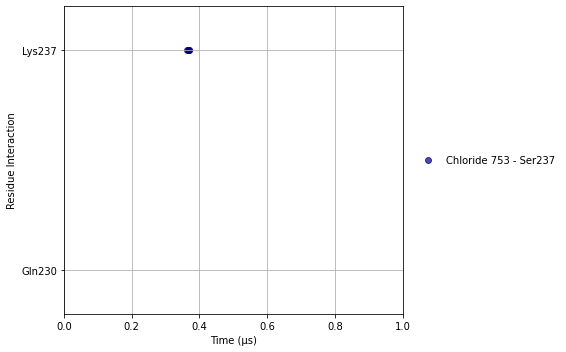


Finished. Data saved and plot generated.
Gln230 counts saved to chloride_contacts_Gln230.txt
Lys237 counts saved to chloride_contacts_Lys237.txt
Combined CSV saved to chloride_contacts_combined.csv
Plot saved to chloride_contacts_vs_time_chainA.png


In [3]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis import distances

def count_unique_bicarb_interactions(u, resnum, bicarb_sel, cutoff=3.5, debug_frames=5):
    """
    Count unique bicarbonate residues (resname O31) interacting with a specific residue (resnum)
    within a cutoff distance, for each frame. Returns a list of sets, each containing unique
    interacting chloride residue IDs for each frame.
    """
    res_group = u.select_atoms(f"protein and segid A and resid {resnum} and not name H*")
    if len(res_group) == 0:
        raise ValueError(f"No heavy atoms found for resid {resnum}")

    bicarb_group = u.select_atoms(f"{bicarb_sel} and not name H*")
    if len(bicarb_group) == 0:
        raise ValueError(f"No heavy atoms found for chloride selection: {bicarb_sel}")

    b_resids = bicarb_group.resids
    res_inds = res_group.indices
    b_inds = bicarb_group.indices

    n_frames = len(u.trajectory)
    interacting_bicarbs = [set() for _ in range(n_frames)]

    for i, ts in enumerate(u.trajectory):
        res_pos = u.atoms[res_inds].positions
        b_pos = u.atoms[b_inds].positions

        pairs, dists = distances.capped_distance(
            res_pos, b_pos,
            max_cutoff=cutoff,
            box=u.dimensions,
            return_distances=True
        )

        if pairs.size > 0:
            mask = (dists < cutoff)
            valid_pairs = pairs[mask]
            b_atom_indices = valid_pairs[:, 1]
            interacting_resids = set(b_resids[b_atom_indices])
            interacting_bicarbs[i] = interacting_resids

        if i < debug_frames and interacting_bicarbs[i]:
            print(f"\nDEBUG: resid {resnum}, Frame {i}, interacting chloride resids = {interacting_bicarbs[i]}")
            for (i_res, i_b), d in zip(pairs[mask], dists[mask]):
                atom_res = res_group.atoms[i_res]
                atom_b = bicarb_group.atoms[i_b]
                print(f"  Residue atom: {atom_res}, Chloride atom: {atom_b}, distance = {d:.4f} Å, b_resid = {b_resids[i_b]}")
            print("-----")

    return interacting_bicarbs

def plot_unique_contacts(interacting_bicarbs_230, interacting_bicarbs_237,
                         time_ns_per_frame=1.0, plotfile="bicarbonate_contacts_vs_time_chainA_out.png"):
    """
    Plot the number of unique chloride residues interacting with residues 230 and 237 over time.
    Each unique chloride is represented by a distinct color.
    Only chloride that appear at least once are shown in the legend.
    """
    n_frames = len(interacting_bicarbs_230)
    times_ns = np.arange(n_frames) * time_ns_per_frame
    times_us = times_ns / 1000.0  # convert ns → µs

    all_bicarbs = set()
    for frame_bicarbs in interacting_bicarbs_230 + interacting_bicarbs_237:
        all_bicarbs.update(frame_bicarbs)

    bicarb_to_color = {bicarb: plt.cm.jet(i / len(all_bicarbs)) for i, bicarb in enumerate(all_bicarbs)}

    plt.figure(figsize=(8, 5))
    used_labels = set()  # to prevent duplicate legend entries

    for bicarb in all_bicarbs:
        # Get the frames where each chloride interacts with either residue
        times_230 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_230) if bicarb in frame_bicarbs]
        times_237 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_237) if bicarb in frame_bicarbs]

        # Only plot (and label) if it actually appears in at least one frame
        if times_230 or times_237:
            color = bicarb_to_color[bicarb]
            label_230 = f"Chloride {bicarb} - Tyr230" if bicarb not in used_labels and times_230 else None
            label_237 = f"Chloride {bicarb} - Ser237" if bicarb not in used_labels and times_237 else None

            if times_230:
                plt.scatter(times_us[times_230], [1] * len(times_230), color=color,
                            label=label_230, alpha=0.7)
            if times_237:
                plt.scatter(times_us[times_237], [2] * len(times_237), color=color,
                            label=label_237, alpha=0.7)

            used_labels.add(bicarb)

    # === Axis and layout settings ===
    plt.xlabel("Time (µs)")
    plt.ylabel("Residue Interaction")
    plt.yticks([1, 2], ['Gln230', 'Lys237'])
    plt.xlim(0, 1)
    plt.ylim(0.8,2.2)
    plt.xticks(np.arange(0, 1.01, 0.2))

    # Legend outside plot (right side)
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(plotfile, dpi=300)
    plt.show() 

def main(topology, traj, cutoff=3.5, time_ns_per_frame=1.0, debug_frames=5, outprefix="chloride_contacts", plotfile="contacts_vs_time_outface.png"):
    u = mda.Universe(topology, traj)
    bicarb_sel = "resname CLA"

    print("Counting unique interactions to Gln230 …")
    interacting_bicarbs_230 = count_unique_bicarb_interactions(u, 230, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)
    print("Counting unique interactions to Ser237 …")
    interacting_bicarbs_237 = count_unique_bicarb_interactions(u, 237, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)

    # Save data
    np.savetxt(f"{outprefix}_Gln230_chainA.txt", [len(frame) for frame in interacting_bicarbs_230], fmt="%d")
    np.savetxt(f"{outprefix}_Lys237_chainA.txt", [len(frame) for frame in interacting_bicarbs_237], fmt="%d")
    with open(f"{outprefix}_combined_chainA.csv", "w") as f:
        f.write("frame,time_us,Gln230,Lys237\n")
        for i in range(len(interacting_bicarbs_230)):
            time_us = (i * time_ns_per_frame) / 1000.0
            f.write(f"{i},{time_us:.6f},{len(interacting_bicarbs_230[i])},{len(interacting_bicarbs_237[i])}\n")

    # Plot
    plot_unique_contacts(interacting_bicarbs_230, interacting_bicarbs_237, time_ns_per_frame=time_ns_per_frame, plotfile=plotfile)

    print("\nFinished. Data saved and plot generated.")
    print(f"Gln230 counts saved to {outprefix}_Gln230.txt")
    print(f"Lys237 counts saved to {outprefix}_Lys237.txt")
    print(f"Combined CSV saved to {outprefix}_combined.csv")
    print(f"Plot saved to {plotfile}")

if __name__ == "__main__":
    # Example usage — change these to your real files
    topology = "pendrin_md_0ns.pdb"
    traj = "pendrin_md_0.5us.dcd"
    cutoff = 3.5
    time_ns_per_frame = 2  # 1 frame = 1 ns
    debug_frames = 5
    main(topology, traj, cutoff=cutoff,
         time_ns_per_frame=time_ns_per_frame,
         debug_frames=debug_frames,
         outprefix="chloride_contacts", plotfile="chloride_contacts_vs_time_chainA.png")

Counting unique interactions to Gln230 …
Counting unique interactions to Ser237 …


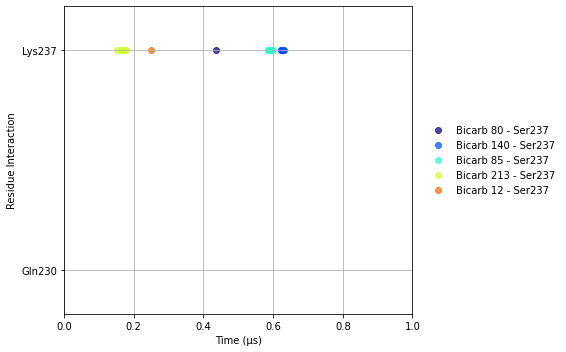


Finished. Data saved and plot generated.
Gln230 counts saved to Bicarb_contacts_Gln230.txt
Lys237 counts saved to Bicarb_contacts_Lys237.txt
Combined CSV saved to Bicarb_contacts_combined.csv
Plot saved to Bicarb_contacts_vs_time_chainB.png


In [2]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis import distances

def count_unique_bicarb_interactions(u, resnum, bicarb_sel, cutoff=3.5, debug_frames=5):
    """
    Count unique bicarbonate residues (resname O31) interacting with a specific residue (resnum)
    within a cutoff distance, for each frame. Returns a list of sets, each containing unique
    interacting chloride residue IDs for each frame.
    """
    res_group = u.select_atoms(f"protein and segid B and resid {resnum} and not name H*")
    if len(res_group) == 0:
        raise ValueError(f"No heavy atoms found for resid {resnum}")

    bicarb_group = u.select_atoms(f"{bicarb_sel} and not name H*")
    if len(bicarb_group) == 0:
        raise ValueError(f"No heavy atoms found for chloride selection: {bicarb_sel}")

    b_resids = bicarb_group.resids
    res_inds = res_group.indices
    b_inds = bicarb_group.indices

    n_frames = len(u.trajectory)
    interacting_bicarbs = [set() for _ in range(n_frames)]

    for i, ts in enumerate(u.trajectory):
        res_pos = u.atoms[res_inds].positions
        b_pos = u.atoms[b_inds].positions

        pairs, dists = distances.capped_distance(
            res_pos, b_pos,
            max_cutoff=cutoff,
            box=u.dimensions,
            return_distances=True
        )

        if pairs.size > 0:
            mask = (dists < cutoff)
            valid_pairs = pairs[mask]
            b_atom_indices = valid_pairs[:, 1]
            interacting_resids = set(b_resids[b_atom_indices])
            interacting_bicarbs[i] = interacting_resids

        if i < debug_frames and interacting_bicarbs[i]:
            print(f"\nDEBUG: resid {resnum}, Frame {i}, interacting bicarb resids = {interacting_bicarbs[i]}")
            for (i_res, i_b), d in zip(pairs[mask], dists[mask]):
                atom_res = res_group.atoms[i_res]
                atom_b = bicarb_group.atoms[i_b]
                print(f"  Residue atom: {atom_res}, Bicarbonate atom: {atom_b}, distance = {d:.4f} Å, b_resid = {b_resids[i_b]}")
            print("-----")

    return interacting_bicarbs

def plot_unique_contacts(interacting_bicarbs_230, interacting_bicarbs_237,
                         time_ns_per_frame=1.0, plotfile="bicarbonate_contacts_vs_time_chainA_out.png"):
    """
    Plot the number of unique chloride residues interacting with residues 230 and 237 over time.
    Each unique chloride is represented by a distinct color.
    Only chloride that appear at least once are shown in the legend.
    """
    n_frames = len(interacting_bicarbs_230)
    times_ns = np.arange(n_frames) * time_ns_per_frame
    times_us = times_ns / 1000.0  # convert ns → µs

    all_bicarbs = set()
    for frame_bicarbs in interacting_bicarbs_230 + interacting_bicarbs_237:
        all_bicarbs.update(frame_bicarbs)

    bicarb_to_color = {bicarb: plt.cm.jet(i / len(all_bicarbs)) for i, bicarb in enumerate(all_bicarbs)}

    plt.figure(figsize=(8, 5))
    used_labels = set()  # to prevent duplicate legend entries

    for bicarb in all_bicarbs:
        # Get the frames where each chloride interacts with either residue
        times_230 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_230) if bicarb in frame_bicarbs]
        times_237 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_237) if bicarb in frame_bicarbs]

        # Only plot (and label) if it actually appears in at least one frame
        if times_230 or times_237:
            color = bicarb_to_color[bicarb]
            label_230 = f"Bicarb {bicarb} - Tyr230" if bicarb not in used_labels and times_230 else None
            label_237 = f"Bicarb {bicarb} - Ser237" if bicarb not in used_labels and times_237 else None

            if times_230:
                plt.scatter(times_us[times_230], [1] * len(times_230), color=color,
                            label=label_230, alpha=0.7)
            if times_237:
                plt.scatter(times_us[times_237], [2] * len(times_237), color=color,
                            label=label_237, alpha=0.7)

            used_labels.add(bicarb)

    # === Axis and layout settings ===
    plt.xlabel("Time (µs)")
    plt.ylabel("Residue Interaction")
    plt.yticks([1, 2], ['Gln230', 'Lys237'])
    plt.xlim(0, 1)
    plt.ylim(0.8,2.2)
    plt.xticks(np.arange(0, 1.01, 0.2))

    # Legend outside plot (right side)
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(plotfile, dpi=300)
    plt.show() 

def main(topology, traj, cutoff=3.5, time_ns_per_frame=1.0, debug_frames=5, outprefix="bicarb_contacts", plotfile="contacts_vs_time_outface.png"):
    u = mda.Universe(topology, traj)
    bicarb_sel = "resname O31"

    print("Counting unique interactions to Gln230 …")
    interacting_bicarbs_230 = count_unique_bicarb_interactions(u, 230, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)
    print("Counting unique interactions to Ser237 …")
    interacting_bicarbs_237 = count_unique_bicarb_interactions(u, 237, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)

    # Save data
    np.savetxt(f"{outprefix}_Gln230_chainB.txt", [len(frame) for frame in interacting_bicarbs_230], fmt="%d")
    np.savetxt(f"{outprefix}_Lys237_chainB.txt", [len(frame) for frame in interacting_bicarbs_237], fmt="%d")
    with open(f"{outprefix}_combined_chainB.csv", "w") as f:
        f.write("frame,time_us,Gln230,Lys237\n")
        for i in range(len(interacting_bicarbs_230)):
            time_us = (i * time_ns_per_frame) / 1000.0
            f.write(f"{i},{time_us:.6f},{len(interacting_bicarbs_230[i])},{len(interacting_bicarbs_237[i])}\n")

    # Plot
    plot_unique_contacts(interacting_bicarbs_230, interacting_bicarbs_237, time_ns_per_frame=time_ns_per_frame, plotfile=plotfile)

    print("\nFinished. Data saved and plot generated.")
    print(f"Gln230 counts saved to {outprefix}_Gln230.txt")
    print(f"Lys237 counts saved to {outprefix}_Lys237.txt")
    print(f"Combined CSV saved to {outprefix}_combined.csv")
    print(f"Plot saved to {plotfile}")

if __name__ == "__main__":
    # Example usage — change these to your real files
    topology = "pendrin_md_0ns.pdb"
    traj = "pendrin_md_0.5us.dcd"
    cutoff = 3.5
    time_ns_per_frame = 2  # 1 frame = 1 ns
    debug_frames = 5
    main(topology, traj, cutoff=cutoff,
         time_ns_per_frame=time_ns_per_frame,
         debug_frames=debug_frames,
         outprefix="Bicarb_contacts", plotfile="Bicarb_contacts_vs_time_chainB.png")

Counting unique interactions to Gln230 …
Counting unique interactions to Ser237 …


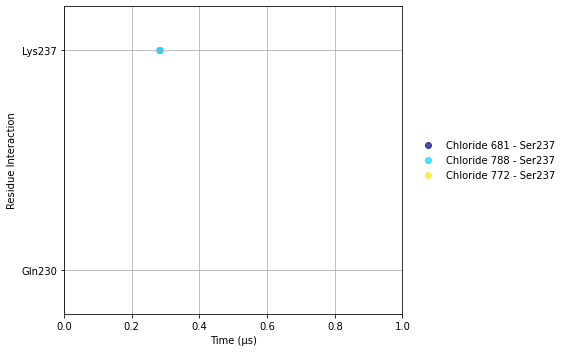


Finished. Data saved and plot generated.
Gln230 counts saved to chloride_contacts_Gln230.txt
Lys237 counts saved to chloride_contacts_Lys237.txt
Combined CSV saved to chloride_contacts_combined.csv
Plot saved to chloride_contacts_vs_time_chainB.png


In [4]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis import distances

def count_unique_bicarb_interactions(u, resnum, bicarb_sel, cutoff=3.5, debug_frames=5):
    """
    Count unique bicarbonate residues (resname O31) interacting with a specific residue (resnum)
    within a cutoff distance, for each frame. Returns a list of sets, each containing unique
    interacting chloride residue IDs for each frame.
    """
    res_group = u.select_atoms(f"protein and segid B and resid {resnum} and not name H*")
    if len(res_group) == 0:
        raise ValueError(f"No heavy atoms found for resid {resnum}")

    bicarb_group = u.select_atoms(f"{bicarb_sel} and not name H*")
    if len(bicarb_group) == 0:
        raise ValueError(f"No heavy atoms found for chloride selection: {bicarb_sel}")

    b_resids = bicarb_group.resids
    res_inds = res_group.indices
    b_inds = bicarb_group.indices

    n_frames = len(u.trajectory)
    interacting_bicarbs = [set() for _ in range(n_frames)]

    for i, ts in enumerate(u.trajectory):
        res_pos = u.atoms[res_inds].positions
        b_pos = u.atoms[b_inds].positions

        pairs, dists = distances.capped_distance(
            res_pos, b_pos,
            max_cutoff=cutoff,
            box=u.dimensions,
            return_distances=True
        )

        if pairs.size > 0:
            mask = (dists < cutoff)
            valid_pairs = pairs[mask]
            b_atom_indices = valid_pairs[:, 1]
            interacting_resids = set(b_resids[b_atom_indices])
            interacting_bicarbs[i] = interacting_resids

        if i < debug_frames and interacting_bicarbs[i]:
            print(f"\nDEBUG: resid {resnum}, Frame {i}, interacting chloride resids = {interacting_bicarbs[i]}")
            for (i_res, i_b), d in zip(pairs[mask], dists[mask]):
                atom_res = res_group.atoms[i_res]
                atom_b = bicarb_group.atoms[i_b]
                print(f"  Residue atom: {atom_res}, Chloride atom: {atom_b}, distance = {d:.4f} Å, b_resid = {b_resids[i_b]}")
            print("-----")

    return interacting_bicarbs

def plot_unique_contacts(interacting_bicarbs_230, interacting_bicarbs_237,
                         time_ns_per_frame=1.0, plotfile="bicarbonate_contacts_vs_time_chainA_out.png"):
    """
    Plot the number of unique chloride residues interacting with residues 230 and 237 over time.
    Each unique chloride is represented by a distinct color.
    Only chloride that appear at least once are shown in the legend.
    """
    n_frames = len(interacting_bicarbs_230)
    times_ns = np.arange(n_frames) * time_ns_per_frame
    times_us = times_ns / 1000.0  # convert ns → µs

    all_bicarbs = set()
    for frame_bicarbs in interacting_bicarbs_230 + interacting_bicarbs_237:
        all_bicarbs.update(frame_bicarbs)

    bicarb_to_color = {bicarb: plt.cm.jet(i / len(all_bicarbs)) for i, bicarb in enumerate(all_bicarbs)}

    plt.figure(figsize=(8, 5))
    used_labels = set()  # to prevent duplicate legend entries

    for bicarb in all_bicarbs:
        # Get the frames where each chloride interacts with either residue
        times_230 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_230) if bicarb in frame_bicarbs]
        times_237 = [i for i, frame_bicarbs in enumerate(interacting_bicarbs_237) if bicarb in frame_bicarbs]

        # Only plot (and label) if it actually appears in at least one frame
        if times_230 or times_237:
            color = bicarb_to_color[bicarb]
            label_230 = f"Chloride {bicarb} - Tyr230" if bicarb not in used_labels and times_230 else None
            label_237 = f"Chloride {bicarb} - Ser237" if bicarb not in used_labels and times_237 else None

            if times_230:
                plt.scatter(times_us[times_230], [1] * len(times_230), color=color,
                            label=label_230, alpha=0.7)
            if times_237:
                plt.scatter(times_us[times_237], [2] * len(times_237), color=color,
                            label=label_237, alpha=0.7)

            used_labels.add(bicarb)

    # === Axis and layout settings ===
    plt.xlabel("Time (µs)")
    plt.ylabel("Residue Interaction")
    plt.yticks([1, 2], ['Gln230', 'Lys237'])
    plt.xlim(0, 1)
    plt.ylim(0.8,2.2)
    plt.xticks(np.arange(0, 1.01, 0.2))

    # Legend outside plot (right side)
    plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

    plt.grid(True)
    plt.tight_layout()
    plt.savefig(plotfile, dpi=300)
    plt.show() 

def main(topology, traj, cutoff=3.5, time_ns_per_frame=1.0, debug_frames=5, outprefix="chloride_contacts", plotfile="contacts_vs_time_outface.png"):
    u = mda.Universe(topology, traj)
    bicarb_sel = "resname CLA"

    print("Counting unique interactions to Gln230 …")
    interacting_bicarbs_230 = count_unique_bicarb_interactions(u, 230, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)
    print("Counting unique interactions to Ser237 …")
    interacting_bicarbs_237 = count_unique_bicarb_interactions(u, 237, bicarb_sel, cutoff=cutoff, debug_frames=debug_frames)

    # Save data
    np.savetxt(f"{outprefix}_Gln230_chainB.txt", [len(frame) for frame in interacting_bicarbs_230], fmt="%d")
    np.savetxt(f"{outprefix}_Lys237_chainB.txt", [len(frame) for frame in interacting_bicarbs_237], fmt="%d")
    with open(f"{outprefix}_combined_chainB.csv", "w") as f:
        f.write("frame,time_us,Gln230,Lys237\n")
        for i in range(len(interacting_bicarbs_230)):
            time_us = (i * time_ns_per_frame) / 1000.0
            f.write(f"{i},{time_us:.6f},{len(interacting_bicarbs_230[i])},{len(interacting_bicarbs_237[i])}\n")

    # Plot
    plot_unique_contacts(interacting_bicarbs_230, interacting_bicarbs_237, time_ns_per_frame=time_ns_per_frame, plotfile=plotfile)

    print("\nFinished. Data saved and plot generated.")
    print(f"Gln230 counts saved to {outprefix}_Gln230.txt")
    print(f"Lys237 counts saved to {outprefix}_Lys237.txt")
    print(f"Combined CSV saved to {outprefix}_combined.csv")
    print(f"Plot saved to {plotfile}")

if __name__ == "__main__":
    # Example usage — change these to your real files
    topology = "pendrin_md_0ns.pdb"
    traj = "pendrin_md_0.5us.dcd"
    cutoff = 3.5
    time_ns_per_frame = 2  # 1 frame = 1 ns
    debug_frames = 5
    main(topology, traj, cutoff=cutoff,
         time_ns_per_frame=time_ns_per_frame,
         debug_frames=debug_frames,
         outprefix="chloride_contacts", plotfile="chloride_contacts_vs_time_chainB.png")